In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# This will ignore all warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [3]:
survey_df = pd.read_csv("../data/Students.csv")

# Dataset Overview (structure)
print("Survey Dataset Info:")
survey_df.info()

print(f"\nSurvey Dataset Shape: {survey_df.shape}")

Survey Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 3614 entries, 0 to 3613
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_Name               3614 non-null   str    
 1   College_Name               3614 non-null   str    
 2   Stream                     3614 non-null   str    
 3   Year_of_Study              3614 non-null   int64  
 4   AI_Tools_Used              3614 non-null   str    
 5   Daily_Usage_Hours          3614 non-null   float64
 6   Use_Cases                  3614 non-null   str    
 7   Trust_in_AI_Tools          3614 non-null   int64  
 8   Impact_on_Grades           3614 non-null   int64  
 9   Do_Professors_Allow_Use    3614 non-null   str    
 10  Preferred_AI_Tool          3614 non-null   str    
 11  Awareness_Level            3614 non-null   int64  
 12  Willing_to_Pay_for_Access  3614 non-null   str    
 13  State                      2000 non-nu

In [4]:
usage_agg = (
    survey_df
    .groupby(['Preferred_AI_Tool', 'Device_Used'])['Daily_Usage_Hours']
    .agg(['sum', 'count'])
    .reset_index()
)

# Rename columns for clarity
usage_agg.rename(columns={'sum': 'Total_Usage_Hours', 'count': 'Response_Count'}, inplace=True)

# Create pivot tables for each metric
usage_pivot = usage_agg.pivot(index='Preferred_AI_Tool', columns='Device_Used', values='Total_Usage_Hours').fillna(0).round(1)
count_pivot = usage_agg.pivot(index='Preferred_AI_Tool', columns='Device_Used', values='Response_Count').fillna(0).astype(int)

# Add Total columns and rows to both
usage_pivot['Total'] = usage_pivot.sum(axis=1)
usage_pivot.loc['Total'] = usage_pivot.sum(axis=0)

count_pivot['Total'] = count_pivot.sum(axis=1)
count_pivot.loc['Total'] = count_pivot.sum(axis=0)

# Display both tables
print("🕓 Total Daily Usage Hours")
print(usage_pivot)

print("\n🔢 Response Count")
print(count_pivot)

🕓 Total Daily Usage Hours
Device_Used        Laptop  Mobile  Tablet   Total
Preferred_AI_Tool                                
Bard                128.3   152.1   143.1   423.5
ChatGPT             772.6   683.8   795.0  2251.4
Claude              160.6   149.3   128.9   438.8
Copilot             894.9   721.3   519.6  2135.8
Gemini              912.4   541.0   741.2  2194.6
Other               601.8   536.7   668.1  1806.6
Total              3470.6  2784.2  2995.9  9250.7

🔢 Response Count
Device_Used        Laptop  Mobile  Tablet  Total
Preferred_AI_Tool                               
Bard                   51      46      54    151
ChatGPT               281     277     301    859
Claude                 58      49      50    157
Copilot               356     268     212    836
Gemini                341     224     289    854
Other                 249     222     286    757
Total                1336    1086    1192   3614


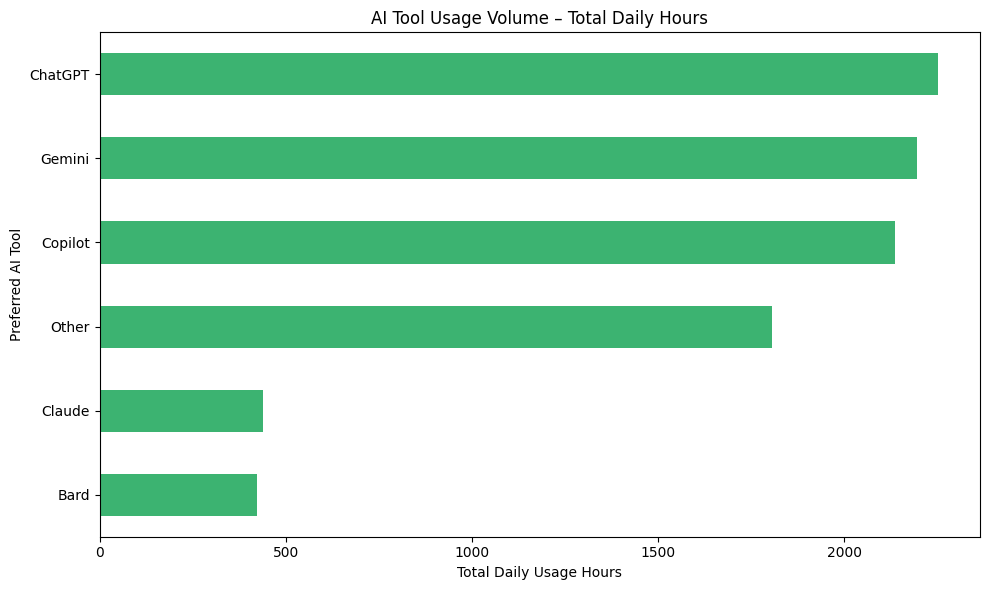

In [5]:
usage_plot = usage_pivot.drop(index='Total').drop(columns='Total')

# Plot total usage per AI Tool (aggregated across devices)
usage_totals = usage_plot.sum(axis=1).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
usage_totals.plot(kind='barh', color='mediumseagreen')
plt.title('AI Tool Usage Volume – Total Daily Hours')
plt.xlabel('Total Daily Usage Hours')
plt.ylabel('Preferred AI Tool')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

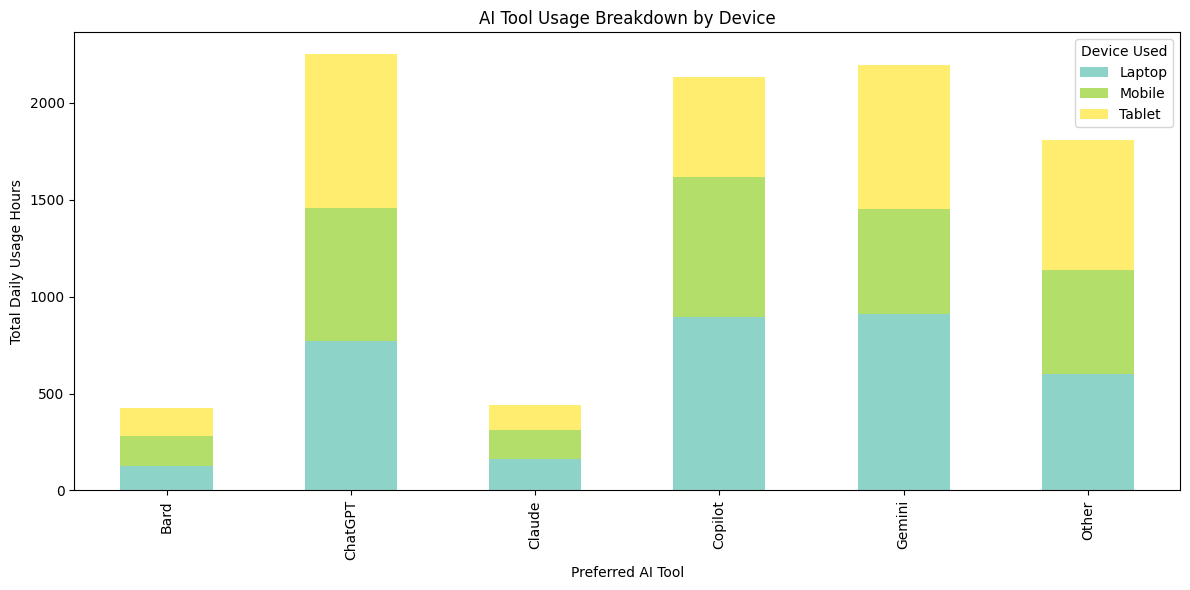

In [6]:
usage_plot.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set3')

plt.title('AI Tool Usage Breakdown by Device')
plt.xlabel('Preferred AI Tool')
plt.ylabel('Total Daily Usage Hours')
plt.legend(title='Device Used')
plt.tight_layout()
plt.show()

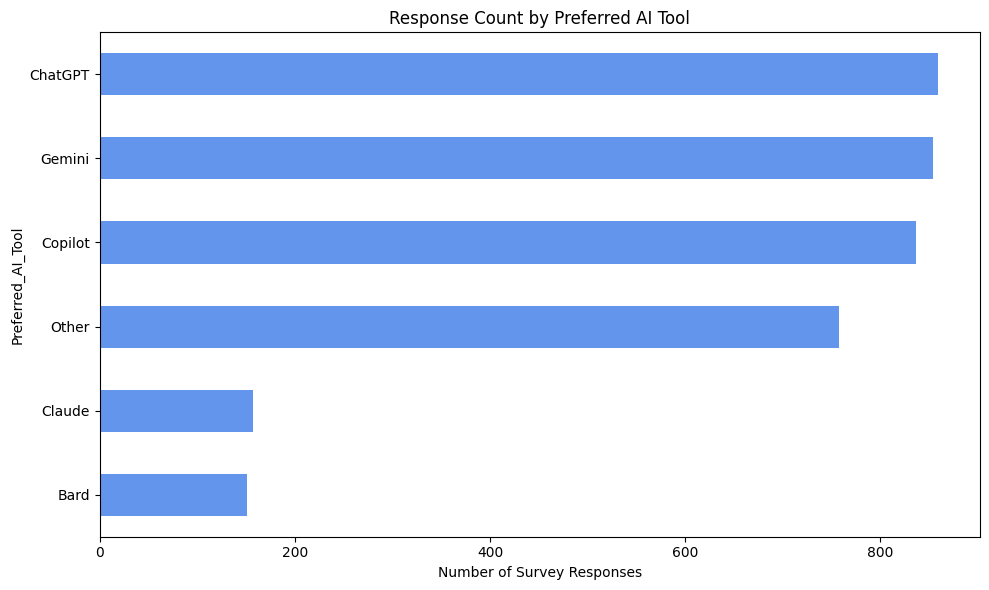

In [7]:
count_plot = count_pivot.drop(index='Total').drop(columns='Total')

# Plot total number of responses per tool
response_totals = count_plot.sum(axis=1).sort_values()

plt.figure(figsize=(10, 6))
response_totals.plot(kind='barh', color='cornflowerblue')
plt.title('Response Count by Preferred AI Tool')
plt.xlabel('Number of Survey Responses')
plt.tight_layout()
plt.show()

In [8]:
tool_state_usage = (
    survey_df
    .groupby(['Preferred_AI_Tool', 'State'])['Daily_Usage_Hours']
    .agg(['sum', 'count', 'mean'])
    .reset_index()
    .rename(columns={
        'sum': 'Total_Usage_Hours',
        'count': 'Response_Count',
        'mean': 'Avg_Hours_Per_User'
    })
)

# Create pivot table of total usage
usage_heatmap = tool_state_usage.pivot(index='Preferred_AI_Tool', columns='State', values='Total_Usage_Hours').fillna(0).round(1)
print(usage_heatmap)

State              Andaman  Andhra pradesh  Arunachal pradesh  Assam  Bihar  \
Preferred_AI_Tool                                                             
Bard                   0.0            23.6                1.2   22.5   13.1   
ChatGPT                0.0            42.9               19.3   24.5   66.7   
Claude                 4.1            10.2                2.9   21.7   14.1   
Copilot                1.5            30.2               39.5   46.4   44.2   
Gemini                 5.0            44.8               18.3   48.2   30.6   
Other                  3.1            60.3               18.4   49.4   34.1   

State              Chandigarh  Chhattisgarh  Dadra  Delhi ncr   Goa  ...  \
Preferred_AI_Tool                                                    ...   
Bard                      4.6          27.9    0.0       24.5   8.0  ...   
ChatGPT                  40.6          36.7    0.0       37.6  12.7  ...   
Claude                    5.9          34.2    0.0       21.0  

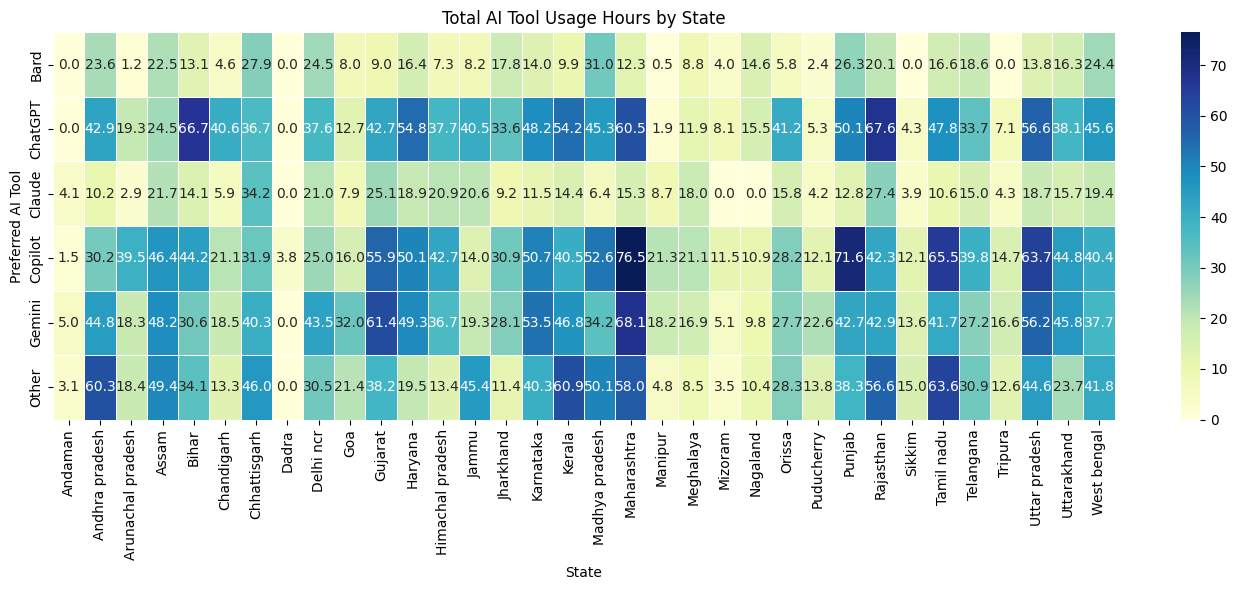

In [9]:
plt.figure(figsize=(14, 6))
sns.heatmap(usage_heatmap, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
plt.title("Total AI Tool Usage Hours by State")
plt.xlabel("State")
plt.ylabel("Preferred AI Tool")
plt.tight_layout()
plt.show()

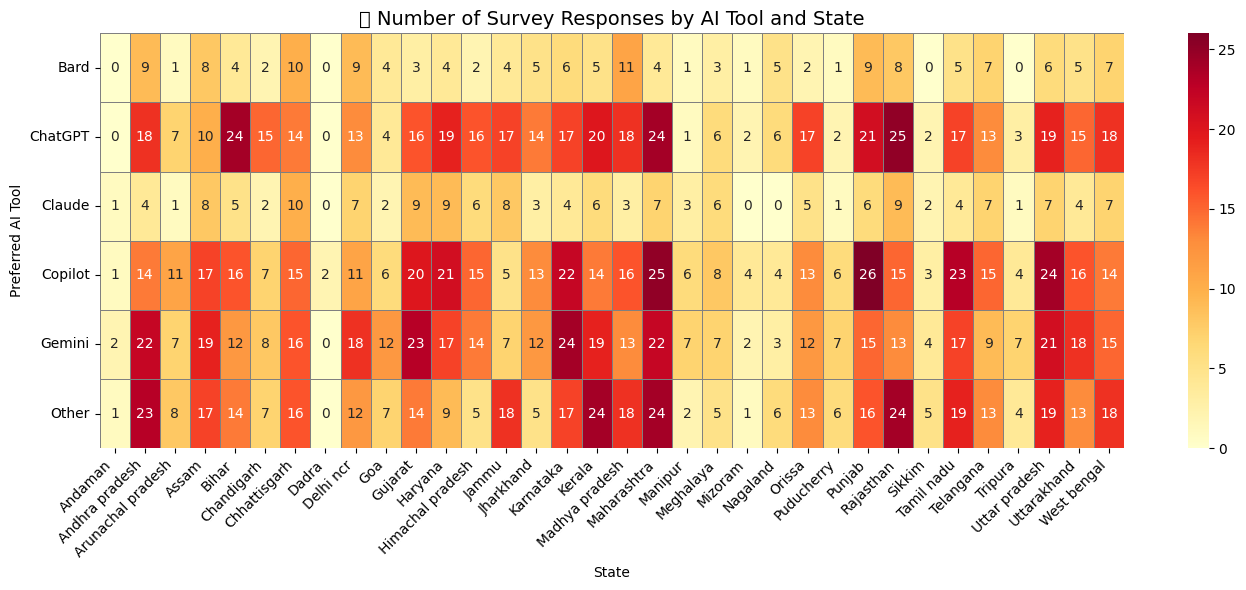

In [10]:
tool_state_counts = (
    survey_df
    .groupby(['Preferred_AI_Tool', 'State'])
    .size()
    .reset_index(name='Response_Count')
)

# Pivot for heatmap
count_matrix = tool_state_counts.pivot(index='Preferred_AI_Tool', columns='State', values='Response_Count').fillna(0).astype(int)

plt.figure(figsize=(14, 6))
sns.heatmap(count_matrix, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, linecolor='gray')

plt.title("🔢 Number of Survey Responses by AI Tool and State", fontsize=14)
plt.xlabel("State")
plt.ylabel("Preferred AI Tool")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

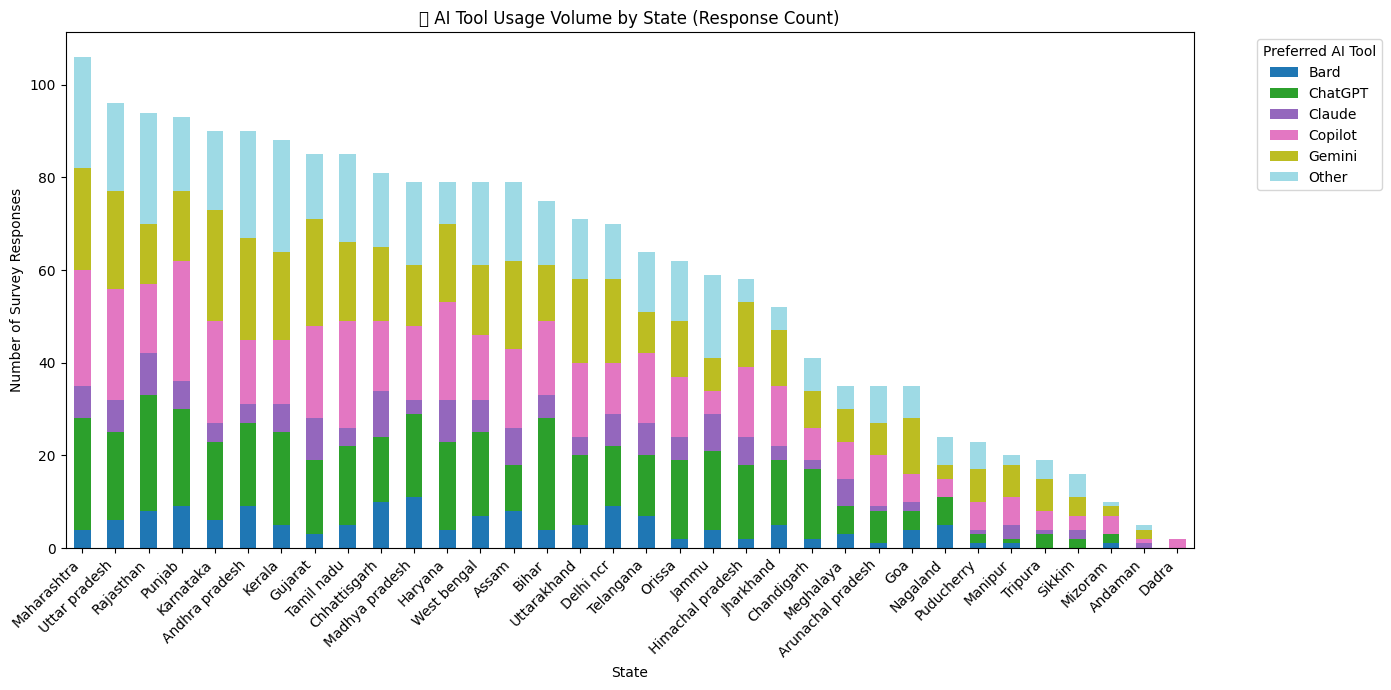

In [11]:
tool_state_counts = (
    survey_df
    .groupby(['State', 'Preferred_AI_Tool'])
    .size()
    .reset_index(name='Response_Count')
)

# Pivot the table so States are rows and Tools are columns
stacked_data = tool_state_counts.pivot(index='State', columns='Preferred_AI_Tool', values='Response_Count').fillna(0)

# Sort by total responses (optional)
stacked_data = stacked_data.loc[stacked_data.sum(axis=1).sort_values(ascending=False).index]

# Plot the stacked bar chart
stacked_data.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20')

plt.title("🧠 AI Tool Usage Volume by State (Response Count)")
plt.xlabel("State")
plt.ylabel("Number of Survey Responses")
plt.legend(title="Preferred AI Tool", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
year_trust_counts = (
    survey_df
    .groupby(['Year_of_Study', 'Trust_in_AI_Tools'])
    .size()
    .reset_index(name='Response_Count')
)

# Pivot to wide format for display
year_trust_table = year_trust_counts.pivot(
    index='Year_of_Study',
    columns='Trust_in_AI_Tools',
    values='Response_Count'
).fillna(0).astype(int)

# Optional: add total per Year
year_trust_table['Total'] = year_trust_table.sum(axis=1)

# Display the table
print("📋 Response Counts by Year of Study vs. Trust_in_AI_Tools")
print(year_trust_table)

📋 Response Counts by Year of Study vs. Trust_in_AI_Tools
Trust_in_AI_Tools    1    2    3    4    5  Total
Year_of_Study                                    
1                  214  156  181  150  201    902
2                  191  186  165  194  230    966
3                  135  212  190  158  186    881
4                  174  196  149  166  180    865


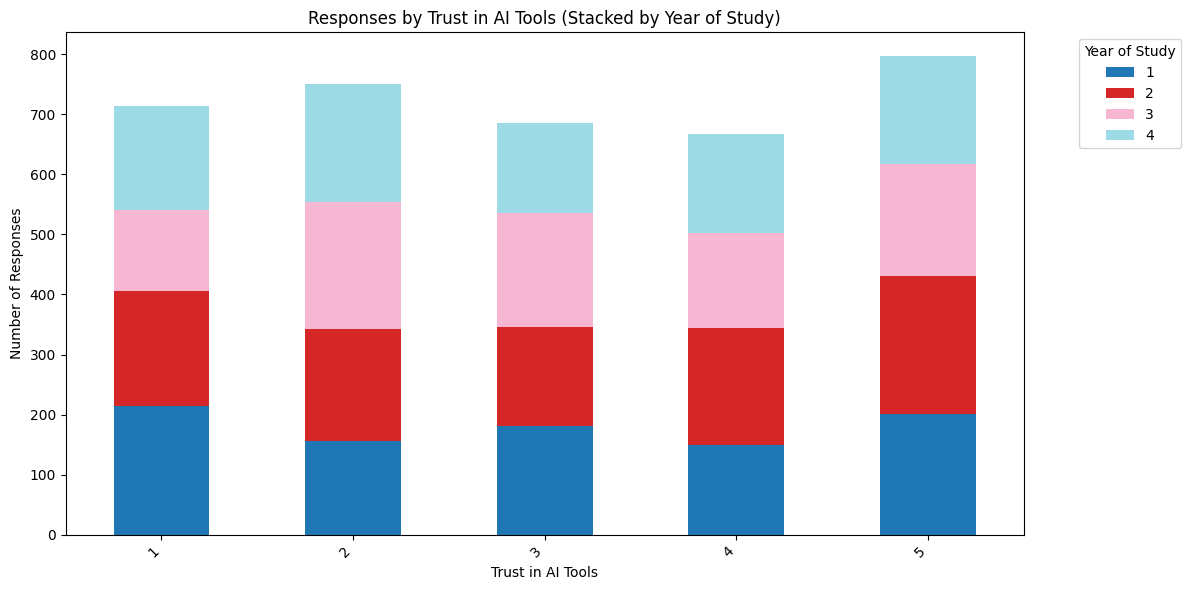

In [13]:
plot_data = year_trust_table.drop(columns='Total', errors='ignore').T  # transpose

# Plot stacked bars with Trust categories on X-axis
plot_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')

plt.title("Responses by Trust in AI Tools (Stacked by Year of Study)")
plt.xlabel("Trust in AI Tools")
plt.ylabel("Number of Responses")
plt.legend(title="Year of Study", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
awareness_tool_counts = (
    survey_df
    .groupby(['Awareness_Level', 'AI_Tools_Used'])
    .size()
    .reset_index(name='Response_Count')
)

# Pivot for comparison table
awareness_tool_table = awareness_tool_counts.pivot(
    index='Awareness_Level',
    columns='AI_Tools_Used',
    values='Response_Count'
).fillna(0).astype(int)

# Optional: add row totals
awareness_tool_table['Total'] = awareness_tool_table.sum(axis=1)

# Display the table
print("📋 Awareness Level vs. AI Tools Used")
print(awareness_tool_table)

📋 Awareness Level vs. AI Tools Used
AI_Tools_Used    Bard  ChatGPT  ChatGPT, Copilot  ChatGPT, Gemini, Copilot  \
Awareness_Level                                                              
1                   8       63                36                        43   
2                  23       32                79                        30   
3                  17       57                39                        29   
4                  17       41                35                        31   
5                  10       50                36                        18   
6                  16       60                40                        44   
7                  17       57                65                        68   
8                  14       85                47                        64   
9                  15       78                78                        56   
10                 14      103                50                        43   

AI_Tools_Used    Claude  Co

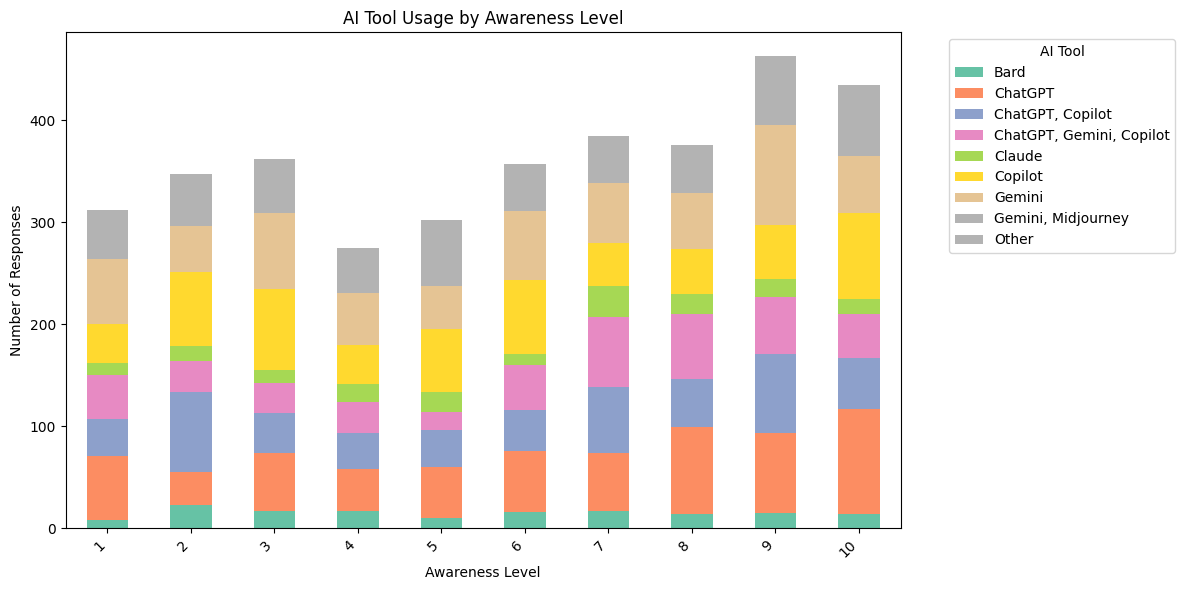

In [15]:
plot_data = awareness_tool_table.drop(columns='Total', errors='ignore')

# Plot
plot_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')

plt.title("AI Tool Usage by Awareness Level")
plt.xlabel("Awareness Level")
plt.ylabel("Number of Responses")
plt.legend(title="AI Tool", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

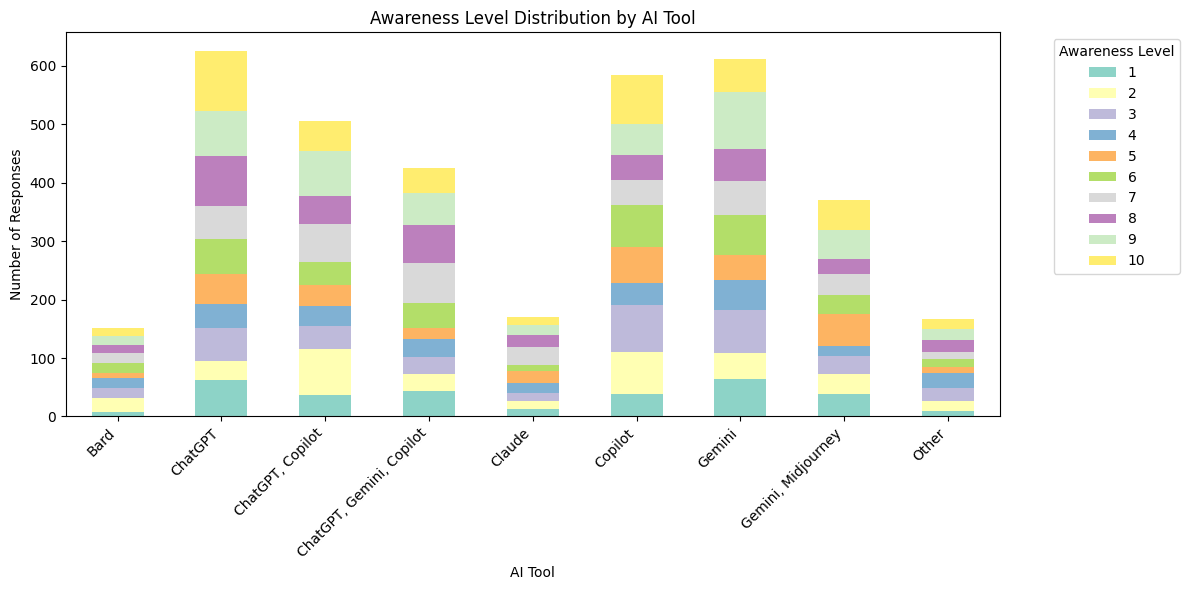

In [16]:
plot_data_tool_x = awareness_tool_table.drop(columns='Total', errors='ignore').T  # Tools as index now

# Plot
plot_data_tool_x.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set3')

plt.title("Awareness Level Distribution by AI Tool")
plt.xlabel("AI Tool")
plt.ylabel("Number of Responses")
plt.legend(title="Awareness Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()